# 02 — What the ensemble recovers

`01_single_particle` showed that one trajectory is ambiguous. This notebook
shows the ensemble diagnostics that resolve the ambiguity, and closes with the
estimator-variance study that says *when* they do.

All logic lives in `collectivediff`; this notebook imports and plots.

In [1]:
import numpy as np

from collectivediff.config import (
    BrownianConfig, CTRWConfig, DDMConfig, FBMConfig, FitConfig,
    LevyWalkConfig, SBMConfig,
)
from collectivediff.estimators import increment_acf, moment_spectrum
from collectivediff.estimators.ergodicity import ctrw_eb_plateau
from collectivediff.generators import generate
from collectivediff.studies import (
    RESULTS_ROOT, benchmark_table, ensemble_msd_curve, ergodicity_checks,
    exponent_spread_study, write_summary,
)
from collectivediff.viz import (
    STYLES, animate_trajectories, plot_amplitude_scatter,
    plot_exponent_spread, plot_increment_acf, plot_moment_spectrum,
    plot_msd, plot_van_hove, save_animation,
)

import dataclasses
from IPython.display import HTML
MEDIA = RESULTS_ROOT / "media"

def show_video(anim, name):
    # A relative path, since nbconvert/Jupyter run with cwd = the notebook's
    # own directory, and that is what a live Jupyter server can actually serve.
    path = save_animation(anim, MEDIA / name, fps=20)
    import os
    rel = os.path.relpath(path, start=".")
    tag = '<video controls loop muted autoplay width="420" src="' + rel + '"></video>'
    return HTML(tag)

N, T = 1500, 2048
FIT = FitConfig(n_bootstrap=60)

## 1. Ensemble MSD

Error bars are bootstrap over particles, never the least-squares residual —
`PROJECT.md` section 2. The shaded band is the fit window; CTRW and the Lévy
walk are fitted from `T/10` because their asymptotics need the first decade
excluded.

In [2]:
MECHANISMS = {
    "brownian": BrownianConfig(n_particles=N, n_steps=T, seed=0),
    "fbm H=0.3": FBMConfig(n_particles=N, n_steps=T, hurst=0.3, seed=0),
    "fbm H=0.7": FBMConfig(n_particles=N, n_steps=T, hurst=0.7, seed=0),
    "sbm a=0.6": SBMConfig(n_particles=N, n_steps=T, alpha=0.6, seed=0),
    "ctrw a=0.5": CTRWConfig(n_particles=N, n_steps=T, alpha_wait=0.5, seed=0),
    "levy_walk g=1.5": LevyWalkConfig(n_particles=N, n_steps=T, gamma=1.5, seed=0),
    "ddm": DDMConfig(n_particles=N, n_steps=T, tau=30.0, seed=0),
}

curves, fits = {}, {}
for label, cfg in MECHANISMS.items():
    t, msd, fit = ensemble_msd_curve(cfg, fit=FIT)
    curves[label], fits[label] = (t, msd), fit

for label, fit in fits.items():
    print(f"{label:<16} alpha = {fit.exponent:.3f} +/- {fit.bootstrap_err:.3f}"
          f"   (true {MECHANISMS[label].alpha_analytic:.2f})")

brownian         alpha = 0.999 +/- 0.014   (true 1.00)
fbm H=0.3        alpha = 0.609 +/- 0.012   (true 0.60)
fbm H=0.7        alpha = 1.399 +/- 0.014   (true 1.40)
sbm a=0.6        alpha = 0.597 +/- 0.014   (true 0.60)
ctrw a=0.5       alpha = 0.498 +/- 0.029   (true 0.50)
levy_walk g=1.5  alpha = 1.534 +/- 0.042   (true 1.50)
ddm              alpha = 1.019 +/- 0.016   (true 1.00)


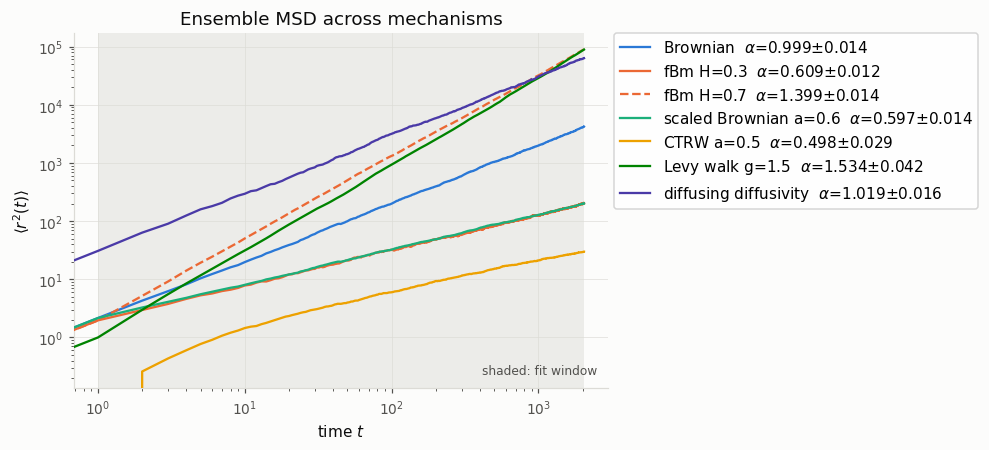

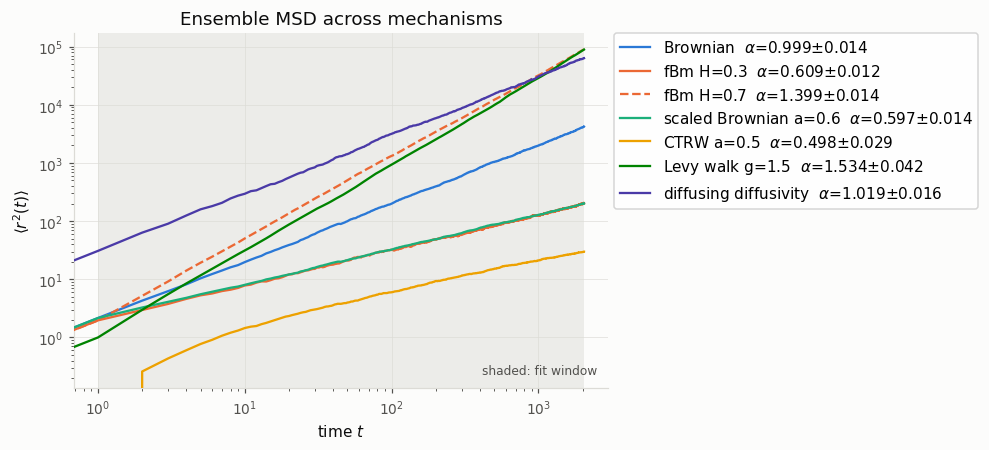

In [3]:
fig = plot_msd(curves, fits, title="Ensemble MSD across mechanisms")
fig

The ensemble recovers every exponent. But notice **fBm H=0.3 and scaled
Brownian α=0.6 lie on top of each other** — same exponent, different mechanism.
The MSD cannot separate them, and neither can any estimator built only on it.
That is `Q2`, and the rest of this notebook is the answer to it.

## 2. van Hove distribution — the shape of the propagator

Diffusing diffusivity is the sharpest case: its MSD is exactly linear, so every
MSD-based observable calls it Brownian. Its *propagator* is not Gaussian.

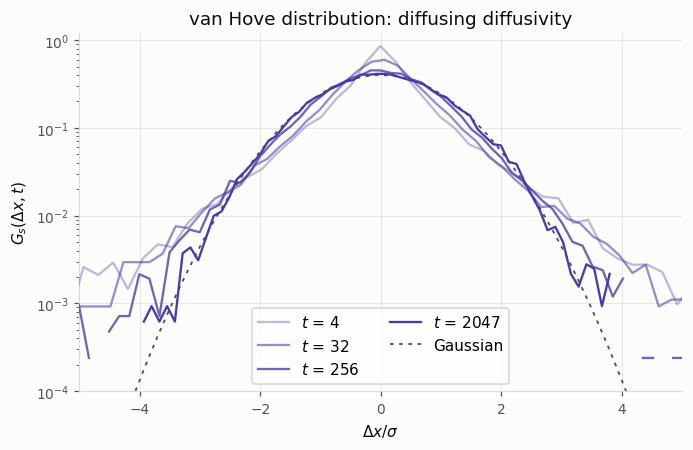

In [4]:
ddm = DDMConfig(n_particles=25000, n_steps=T, tau=50.0, n_aux=1, seed=0)
fig = plot_van_hove(generate(ddm, np.random.default_rng(ddm.seed)),
                    [4, 32, 256, T - 1], mechanism="ddm")
fig

At `t << τ` the distribution has a sharp cusp and exponential tails well above
the Gaussian; by `t >> τ` the walker has averaged over many diffusivities and
the curve relaxes onto it. Brownian yet non-Gaussian (Chechkin et al., PRX 7,
021002) — invisible to the MSD, obvious here.

## 3. Amplitude scatter and ergodicity breaking

`ξ = TA-MSD / ⟨TA-MSD⟩` for each trajectory. An ergodic process concentrates on
`ξ = 1`; a subdiffusive CTRW does not, and keeps a finite density at `ξ = 0` —
trajectories that spent the whole measurement inside one trapping event.

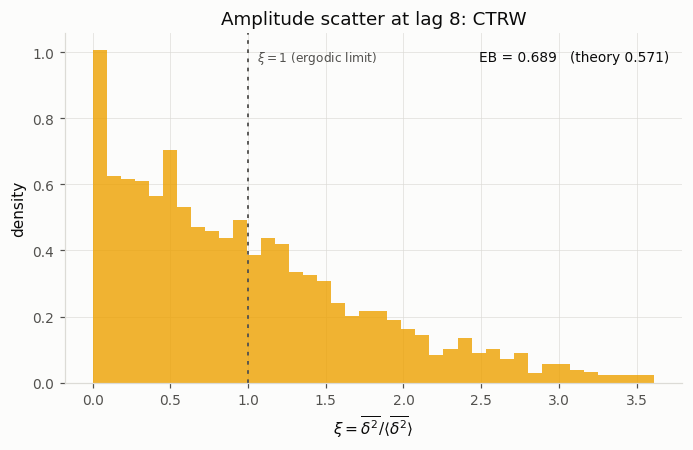

In [5]:
ctrw = CTRWConfig(n_particles=2000, n_steps=4096, alpha_wait=0.5, seed=0)
fig = plot_amplitude_scatter(generate(ctrw, np.random.default_rng(ctrw.seed)),
                             lag=8, mechanism="ctrw", cfg=ctrw,
                             plateau=ctrw_eb_plateau(0.5))
fig

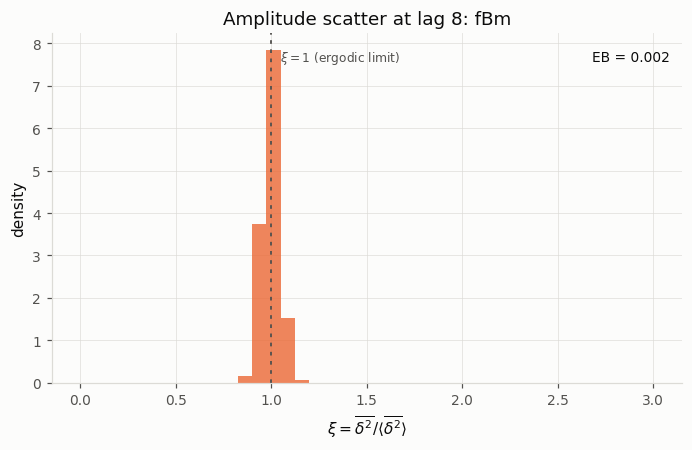

In [6]:
fbm = FBMConfig(n_particles=2000, n_steps=4096, hurst=0.35, seed=0)
fig = plot_amplitude_scatter(generate(fbm, np.random.default_rng(fbm.seed)),
                             lag=8, mechanism="fbm", cfg=fbm)
fig

Same subdiffusive regime, opposite ergodic behaviour. The fBm histogram is a
narrow spike on `ξ = 1` and its EB parameter decays as `1/T`; the CTRW's is
broad and its EB sits on a plateau that no longer trajectory removes.

### The two numeric checks

The CTRW plateau alone is a weak test of the *implementation*: a plateau
multiplied by the wrong constant is still a plateau. The Brownian positive
control, `EB(D) ~= 4D/(3T)`, has a specific slope AND a specific
coefficient, and cannot pass by coincidence.

In [7]:
checks = ergodicity_checks(alpha_wait=0.5, n_particles=2000, n_steps=4096,
                           lags=(10, 50, 100))

print("CTRW EB(lag) vs plateau", round(checks["ctrw"]["plateau"], 4), ":")
for lag, val, dev in zip(checks["lags"], checks["ctrw"]["measured"],
                         checks["ctrw"]["relative_deviation"]):
    print(f"  lag={lag:>4}  measured={val:.4f}  rel.dev={dev:+.1%}")

print()
print("Brownian EB(lag) vs 4*lag/(3T):")
for lag, val, pred in zip(checks["lags"], checks["brownian"]["measured"],
                          checks["brownian"]["predicted"]):
    print(f"  lag={lag:>4}  measured={val:.5f}  predicted={pred:.5f}")

write_summary("ergodicity_checks", checks)

CTRW EB(lag) vs plateau 0.5708 :
  lag=  10  measured=0.7000  rel.dev=+22.6%
  lag=  50  measured=0.8658  rel.dev=+51.7%
  lag= 100  measured=1.0090  rel.dev=+76.8%

Brownian EB(lag) vs 4*lag/(3T):
  lag=  10  measured=0.00354  predicted=0.00326
  lag=  50  measured=0.01734  predicted=0.01628
  lag= 100  measured=0.03442  predicted=0.03256


PosixPath('/Users/faraz/Documents/SBU/Project/results/ergodicity_checks.json')

The Brownian control lands within about 9 per cent of its closed form at
every lag -- the implementation's constant is right, not merely its shape.
The CTRW measurement sits *above* the plateau at every lag shown here, and
increasingly so as the lag grows relative to T: +23% at lag=10, +52% at
lag=50, +77% at lag=100 (T=4096). Consistent with the fact that EB rises
with lag/T, the plateau is approached only as T is pushed far beyond any
single lag -- convergence is genuinely slow, which is why it is quoted as
a limit rather than read off one (T, lag) pair.

## 4. Increment autocorrelation — the memory

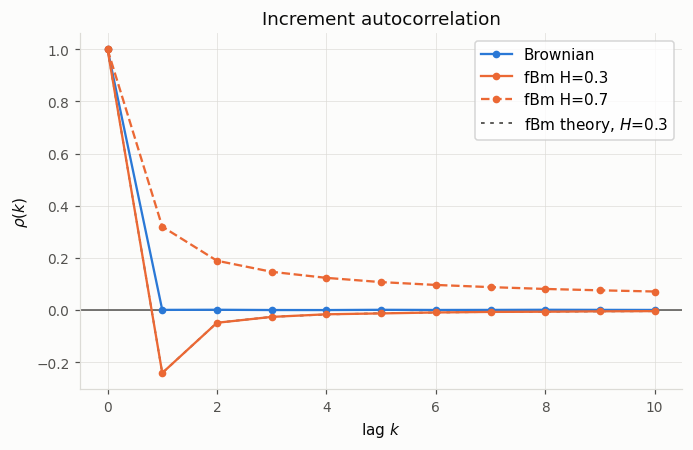

In [8]:
acf = {
    label: increment_acf(generate(MECHANISMS[label],
                                  np.random.default_rng(MECHANISMS[label].seed)), 10)
    for label in ("brownian", "fbm H=0.3", "fbm H=0.7")
}
fig = plot_increment_acf(acf, hurst_reference=0.3)
fig

The dashed theory line sits exactly on the H=0.3 measurement — the Davies–Harte
sampler is exact, not approximate. `H < 1/2` anticorrelates, `H > 1/2`
persists, Brownian is a delta. Scaled Brownian motion would also give a delta
here despite sharing fBm's exponent: **this is what separates the two curves
that overlapped in figure 1.**

## 5. Moment scaling spectrum — strong anomalous diffusion

Fit `⟨|x|^q⟩ ~ t^(q ν(q))` across `q`. A flat `ν(q)` means simple scaling. A
kink means the bulk and the tail of the distribution grow at different rates,
and is the only unambiguous signature of a Lévy walk.

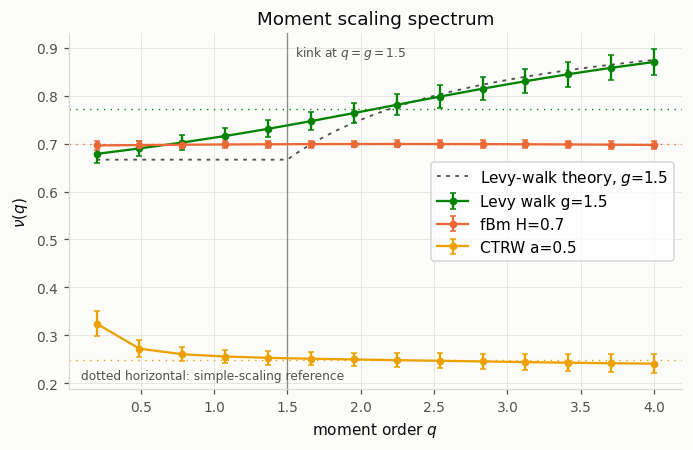

In [9]:
spectra = {}
for label in ("levy_walk g=1.5", "fbm H=0.7", "ctrw a=0.5"):
    cfg = MECHANISMS[label]
    x = generate(cfg, np.random.default_rng(cfg.seed))
    t_min = cfg.duration / 10 if label.split()[0] in ("ctrw", "levy_walk") else 1.0
    spectra[label] = moment_spectrum(x, np.linspace(0.2, 4.0, 14),
                                     t_min, cfg.duration, fit=FIT)

fig = plot_moment_spectrum(spectra, gamma_reference=1.5)
fig

fBm and CTRW are flat — one exponent describes them completely. The Lévy walk
rises and matches the analytic bilinear form `ν(q) = max(1/g, 1 − (g−1)/q)`,
with its kink at `q = g`. Putting `q = 2` there recovers `⟨x²⟩ ~ t^(3−g)`; `q = 4`
gives `⟨x⁴⟩ ~ t^(5−g)`, which is why a Lévy walk's MSD estimator gets *noisier*
as time grows.

## 6. Estimator-variance study

The closing question of phase 1: as the observation lengthens, does a
single-trajectory estimate converge on the truth? For each mechanism, 200
independent trajectories, each fitted on its own TA-MSD, at four lengths.

**This measures scatter in the fitted slope of a single trajectory's
TA-MSD curve** -- a different quantity from section 3's EB parameter,
which measures scatter in the TA-MSD amplitude at one fixed lag. Both
come from the same non-ergodicity but must not be quoted for each other.

In [10]:
STUDY = {
    "brownian": BrownianConfig(seed=0),
    "fbm H=0.3": FBMConfig(hurst=0.3, seed=0),
    "sbm a=0.6": SBMConfig(alpha=0.6, seed=0),
    "ctrw a=0.5": CTRWConfig(alpha_wait=0.5, seed=0),
}
spread, truths, summary = exponent_spread_study(
    STUDY, lengths=(128, 512, 2048, 8192), n_trajectories=200)

for label, s in summary.items():
    print(f"{label:<12} true={s["truth"]:.2f}  median={[round(v, 2) for v in s["median"]]}  IQR={[round(v, 3) for v in s["iqr"]]}")
    print(f"{"":<12} IQR ~ T^-p with p={s["p"]:.3f}  censored={[round(c, 3) for c in s["censored"]]}")

write_summary("exponent_spread", summary)

brownian     true=1.00  median=[0.96, 0.98, 1.0, 0.99]  IQR=[0.215, 0.135, 0.101, 0.07]
             IQR ~ T^-p with p=0.263  censored=[0.0, 0.0, 0.0, 0.0]
fbm H=0.3    true=0.60  median=[0.6, 0.59, 0.59, 0.59]  IQR=[0.182, 0.147, 0.073, 0.062]
             IQR ~ T^-p with p=0.283  censored=[0.0, 0.0, 0.0, 0.0]
sbm a=0.6    true=0.60  median=[0.93, 0.95, 0.97, 0.98]  IQR=[0.215, 0.142, 0.109, 0.07]
             IQR ~ T^-p with p=0.260  censored=[0.0, 0.0, 0.0, 0.0]
ctrw a=0.5   true=0.50  median=[0.93, 0.92, 0.86, 0.88]  IQR=[0.408, 0.364, 0.284, 0.271]
             IQR ~ T^-p with p=0.107  censored=[0.075, 0.035, 0.015, 0.015]


PosixPath('/Users/faraz/Documents/SBU/Project/results/exponent_spread.json')

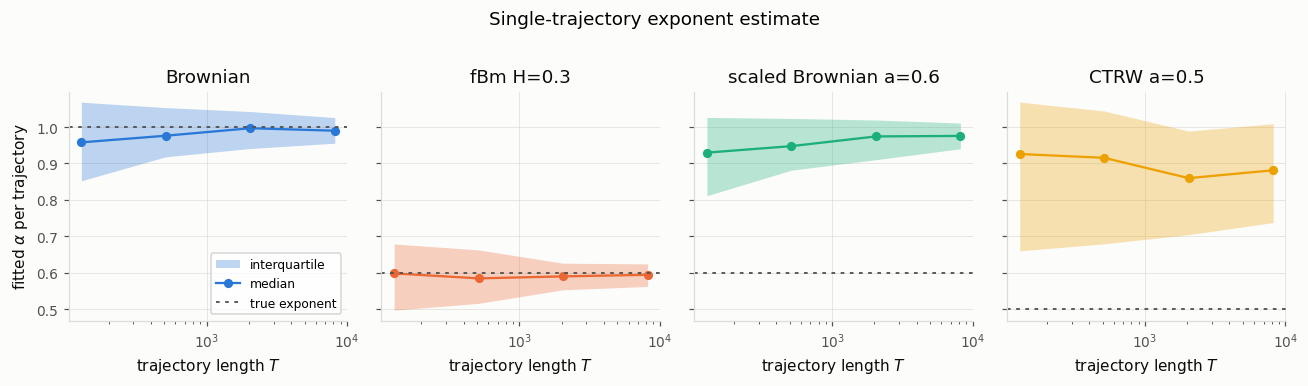

In [11]:
fig = plot_exponent_spread(spread, truths)
fig

### The result of phase 1 -- corrected framing

Fitting `IQR ~ T^-p` across the four lengths puts a number on what the
panels above show:

| mechanism | true alpha | p (IQR ~ T^-p) | bias at T=8192 |
|---|---|---|---|
| Brownian | 1.00 | ~0.26 | ~-0.01 |
| fBm H=0.3 | 0.60 | ~0.28 | ~-0.01 |
| scaled Brownian | 0.60 | ~0.26 | **~+0.38** |
| CTRW a=0.5 | 0.50 | **~0.11** | **~+0.38** |

**The CTRW spread does shrink** -- roughly three times slower than the
ergodic mechanisms (p about 0.11 against about 0.27), not zero. The
actual result is stronger than "the variance stays large": for CTRW and
scaled Brownian motion the single-trajectory estimator *converges*, and
converges to the wrong answer. Both march toward `alpha ~ 1` while the
truth is 0.50 and 0.60 -- this is the He-Burov-Metzler-Barkai result
that a CTRW's time-averaged MSD is linear in lag regardless of `a`, and
it is a **bias** result, not a variance result.

An observer watching one agent for longer is not facing noise that
patience would cure. They are facing a confident wrong answer, and
nothing in their own data -- including their own fit's error bar --
warns them of it, because the estimate keeps getting *tighter* around
the wrong value. That is a stronger motivation for `Q3` and `Q4` than
"the variance is large": the way to learn the true exponent is to
observe more agents, not to watch one for longer.

## 7. The ensemble, animated

In [12]:
cloud = FBMConfig(n_particles=1500, n_steps=600, hurst=0.7, n_dim=2, seed=0)
walk = generate(cloud, np.random.default_rng(cloud.seed))
anim = animate_trajectories(walk, dataclasses.replace(STYLES["cloud"], n_particles=1500, max_frames=70),
                            mechanism=cloud,
                            title="1500 superdiffusive walkers (fBm, H=0.7)")
show_video(anim, "fbm_cloud.mp4")

## 8. Timing and peak memory

Requested at the end of step 3: how expensive each generator and
estimator is, at N=4000, T=4096. Peak memory is dominated by the
*generators*, not the estimators -- the Levy walk and fBm allocate
several times their output array.

In [13]:
table = benchmark_table(n_particles=4000, n_steps=4096)
print(f"float64 array baseline: {table["float64_array_mib"]} MiB")
for row in table['rows']:
    print(f"  {row["operation"]:<28} {row["ms"]:>6} ms   peak {row["peak_mib"]:>5} MiB")

write_summary("benchmark_table", table)

float64 array baseline: 125 MiB
  generate brownian               863 ms   peak   266 MiB
  generate fbm                   2987 ms   peak   937 MiB
  generate sbm                    471 ms   peak   266 MiB
  generate ctrw                  2472 ms   peak   267 MiB
  generate levy_walk             6592 ms   peak  1324 MiB
  generate levy_flight           4259 ms   peak   750 MiB
  generate ddm                   2669 ms   peak   641 MiB
  squared_displacement            225 ms   peak   375 MiB
  ea_msd                          344 ms   peak   375 MiB
  ta_msd (32 lags)               6388 ms   peak   376 MiB
  eb curve (32 lags)             6451 ms   peak   376 MiB
  increment_acf (32)             4215 ms   peak   250 MiB
  fit_powerlaw (no bootstrap)     166 ms   peak     0 MiB
  fit_powerlaw (200 bootstrap)   2572 ms   peak   137 MiB
  moment_spectrum (16 q)        15221 ms   peak   250 MiB


PosixPath('/Users/faraz/Documents/SBU/Project/results/benchmark_table.json')

---

Phase 1 answers `Q1` and `Q2`: which observables recover an exponent, which
separate mechanisms that share one, and where a single trajectory fails in
principle rather than from noise. Phase 2 turns this into a confusion matrix.